# FYS-STK4155 Project 3

Before running the notebook, set DATA_DIR in the first cell to point to your local dataset folder.

Below the code for K-means clustering, PCA, and necessary preprocessing.

To start, download the dataset and unzip it to a folder named data/ in the Project3 directory. Here is the link: https://drive.google.com/file/d/1Z8IdHF6iOaJ5Ju3LMlaQQGKq4GCqc79b/view?usp=sharing

Contains resampled cells size 32x32x3
Split:

80% train:
    416 dead
    - 1131 live

10% dev:
    52 dead
    - 141 live

10% test:
    52 dead
    - 142 live

In [1]:
# Streamline imports and data loading via p3_module
import os
import numpy as np
from p3_module import set_seed, load_split, extract_cell_features, best_flip, plot_confusion
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, f1_score, accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler

# Set data dir and seed
DATA_DIR = r"../data/cells"
SEED = 42
set_seed(SEED)

# Load splits
X_train, y_train = load_split(DATA_DIR, "train")
X_dev, y_dev     = load_split(DATA_DIR, "dev")
X_test, y_test   = load_split(DATA_DIR, "test")
print("Loaded shapes:", X_train.shape, X_dev.shape, X_test.shape)

Loaded shapes: (1547, 32, 32, 3) (193, 32, 32, 3) (194, 32, 32, 3)


### Inspec the dataset for sanity

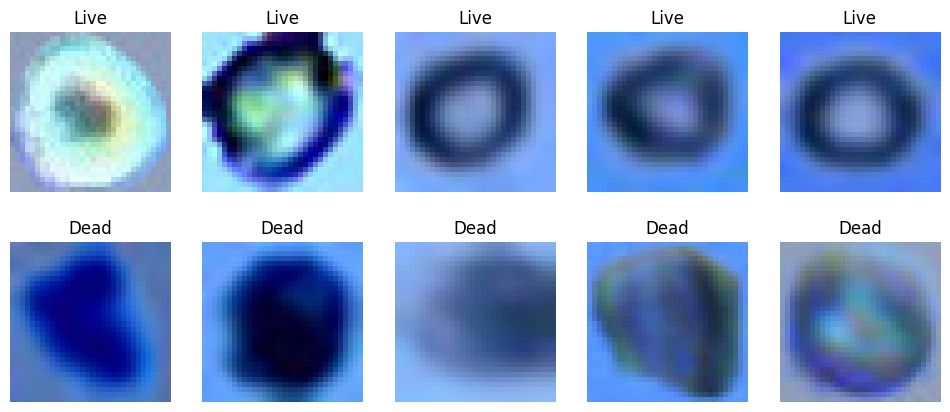

In [2]:
# Display some examples of the live class and dead class
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_train[y_train == 0][i])
    axes[0, i].set_title("Live")
    axes[0, i].axis('off')
    axes[1, i].imshow(X_train[y_train == 1][i])
    axes[1, i].set_title("Dead")
    axes[1, i].axis('off')
plt.show()


In [3]:
# Quick verification: per-split class counts (0=live, 1=dead)
import numpy as np
def _counts(y):
    return {0: int(np.sum(y == 0)), 1: int(np.sum(y == 1))}
print("Train counts:", _counts(y_train))
print("Dev counts:", _counts(y_dev))
print("Test counts:", _counts(y_test))

Train counts: {0: 1131, 1: 416}
Dev counts: {0: 141, 1: 52}
Test counts: {0: 142, 1: 52}


## Preprocessing with PCA



Shape of PCA transformed data: (1547, 3)


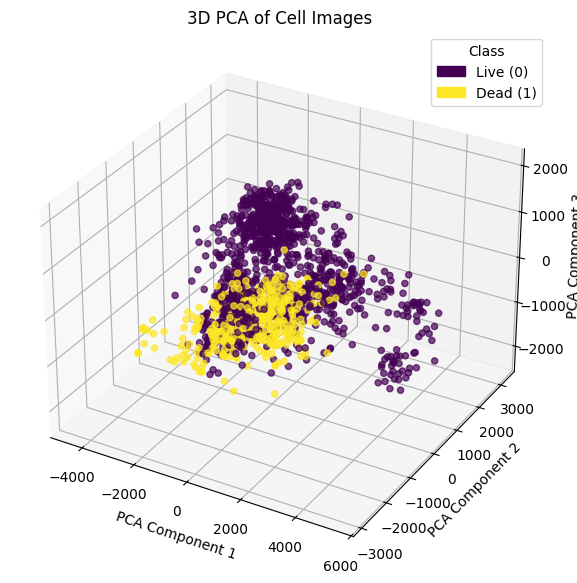

In [4]:
# PCA via module helper
from p3_module import fit_pca
pca, X_train_pca = fit_pca(X_train, n_components=3)
print(f"Shape of PCA transformed data: {X_train_pca.shape}")

# 3D plot of PCA components
import matplotlib.pyplot as plt
import matplotlib as mpl

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='viridis', alpha=0.7)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA of Cell Images')

cmap = plt.cm.viridis
live_patch = mpl.patches.Patch(color=cmap(0.0), label='Live (0)')
dead_patch = mpl.patches.Patch(color=cmap(1.0), label='Dead (1)')
ax.legend(handles=[live_patch, dead_patch], title='Class', loc='best')

plt.show()

## K-Means clustering

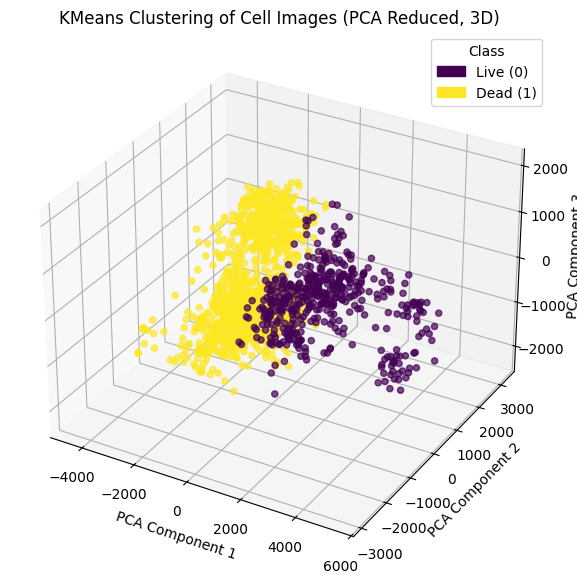

In [5]:
# KMeans clustering using module helper + prediction
from p3_module import fit_kmeans, pca_kmeans_predict
kmeans = fit_kmeans(X_train_pca, n_clusters=2, seed=SEED)
y_pred = pca_kmeans_predict(X_train, pca, kmeans, invert_labels=True)

# Plot the clustered data in 3D (PC1, PC2, PC3)
import matplotlib.pyplot as plt
import matplotlib as mpl
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_pred, cmap='viridis', alpha=0.7)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('KMeans Clustering of Cell Images (PCA Reduced, 3D)')

cmap = plt.cm.viridis
live_patch = mpl.patches.Patch(color=cmap(0.0), label='Live (0)')
dead_patch = mpl.patches.Patch(color=cmap(1.0), label='Dead (1)')
ax.legend(handles=[live_patch, dead_patch], title='Class', loc='best')
plt.show()

In [6]:
# Timing PCA fit_transform and KMeans clustering (k=2)
import time

# Time PCA fit + transform on training data
_t0 = time.time()
X_train_flat = X_train.reshape(X_train.shape[0], -1)
pca_timed = PCA(n_components=3)
X_train_pca_timed = pca_timed.fit_transform(X_train_flat)
pca_time_s = time.time() - _t0
print(f"PCA fit+transform time: {pca_time_s:.4f}s")

# Time KMeans clustering with k=2 on PCA features
_t1 = time.time()
kmeans_timed = KMeans(n_clusters=2, random_state=42)
kmeans_timed.fit(X_train_pca_timed)
kmeans_time_s = time.time() - _t1
print(f"KMeans (k=2) fit time: {kmeans_time_s:.4f}s")

# Keep references for later comparison (optional prediction)
y_pred_timed = kmeans_timed.labels_

PCA fit+transform time: 0.0878s
KMeans (k=2) fit time: 0.0060s


In [7]:
# Use module prediction wrapper instead of defining locally
from p3_module import pca_kmeans_predict
def pca_kmeans_model(X):
    return pca_kmeans_predict(X, pca, kmeans, invert_labels=True)

## F1 Score
The F1 score is the harmonic mean of precision and recall:
$$F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$
with
$$\text{precision} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}}\quad\text{and}\quad\text{recall} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}.$$
Here TP, FP, FN denote true positives, false positives, and false negatives.
We chose to use the F1 score because it gives a more vair evaluation metric when there is class imbalance like we see in our dataset. That is, we have more live cell examples than dead cell examples.

In [8]:
# Calculate the accuracy and F1 score for the pca_kmeans_model on the training and the dev sets
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
y_train_pred = pca_kmeans_model(X_train)
y_dev_pred = pca_kmeans_model(X_dev)
train_accuracy = accuracy_score(y_train, y_train_pred)
dev_accuracy = accuracy_score(y_dev, y_dev_pred)

#Calculate the confusion matrix
dev_confusion_matrix_kmeans = confusion_matrix(y_dev, y_dev_pred)
print(f"Development Confusion Matrix: \n{dev_confusion_matrix_kmeans}")

# Calculate the ROC AUC scores
auc = roc_auc_score(y_train, y_train_pred)
print(f"Training AUC: {auc:.4f}")

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Development Accuracy: {dev_accuracy:.4f}")
train_f1 = f1_score(y_train, y_train_pred)
dev_f1 = f1_score(y_dev, y_dev_pred)
print(f"Training F1 Score: {train_f1:.4f}")
print(f"Development F1 Score: {dev_f1:.4f}")

# Alias for plotting later without recomputation
dev_f1_kmeans = dev_f1
dev_roc_auc_kmeans = auc
dev_accuracy_kmeans = dev_accuracy

Development Confusion Matrix: 
[[ 30 111]
 [ 18  34]]
Training AUC: 0.4615
Training Accuracy: 0.3704
Development Accuracy: 0.3316
Training F1 Score: 0.3601
Development F1 Score: 0.3452


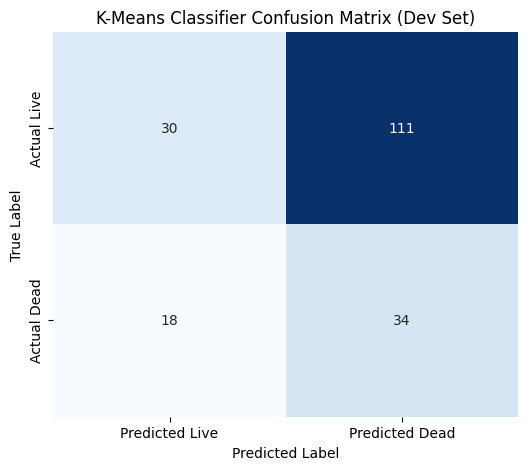

In [9]:
# Plot the confusion matrix for the k-means model via module
from p3_module import plot_confusion
plot_confusion(dev_confusion_matrix_kmeans, 'K-Means Classifier Confusion Matrix (Dev Set)')

## PCA + K-means with manual feature engineering
Since raw pixel fails > feature engineering (rewrite it coherently)

In [10]:
# Final selected parameters (chosen via dev-set sweep)
FINAL_PARAMS = dict(
    center_r=2.5,
    ring_r1=4.0,
    ring_r2=7.0,
    dark_thr=0.30,
)
n_components_final=3

In [11]:
import time
_t0 = time.time()

F_train = extract_cell_features(X_train, **FINAL_PARAMS)
F_dev   = extract_cell_features(X_dev, **FINAL_PARAMS)

scaler = StandardScaler()
F_train_s = scaler.fit_transform(F_train)
F_dev_s   = scaler.transform(F_dev)

pca_feat = PCA(n_components=n_components_final, random_state=SEED)
Z_train = pca_feat.fit_transform(F_train_s)
Z_dev   = pca_feat.transform(F_dev_s)

kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=50)
kmeans.fit(Z_train)

dev_labels_feat = best_flip(y_dev, kmeans.predict(Z_dev))

feature_pca_time_s = time.time() - _t0
print(f"Feature PCA + KMeans total time: {feature_pca_time_s:.4f}s")

Feature PCA + KMeans total time: 0.6366s


[[93 48]
 [ 1 51]]


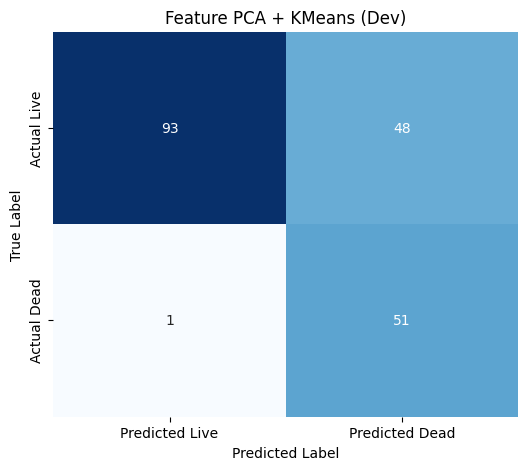

In [12]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score, confusion_matrix

# Feature-based KMeans metrics
dev_accuracy_feat_kmeans = accuracy_score(y_dev, dev_labels_feat)
dev_f1_feat_kmeans       = f1_score(y_dev, dev_labels_feat)
dev_bal_acc_feat_kmeans  = balanced_accuracy_score(y_dev, dev_labels_feat)
dev_roc_auc_feat_kmeans  = roc_auc_score(y_dev, dev_labels_feat)

dev_confusion_matrix_feat_kmeans = confusion_matrix(y_dev, dev_labels_feat)

print(dev_confusion_matrix_feat_kmeans)
plot_confusion(dev_confusion_matrix_feat_kmeans, "Feature PCA + KMeans (Dev)")

# MLP on PCA embedding space

## Neural Network Architecture (MLPClassifier)

**Layer 1 - Input Layer**
- Size: *PCA feature dimension*  
- Receives standardized PCA features.

**Layer 2 - Hidden Layer 1**
- 64 neurons  
- Activation: **ReLU**  
- Regularization: **L2 weight decay** (alpha = 1e-4)

**Layer 3 - Hidden Layer 2**
- 64 neurons  
- Activation: **ReLU**  
- Regularization: **L2 weight decay** (alpha = 1e-4)

**Layer 4 - Output Layer**
- Size: number of classes (`len(np.unique(y_train))`)  
- Activation: **Softmax** (handled internally)


## Training Details
- Optimizer: **Adam** 
- Loss Function: **Cross-entropy**  
- Max Iterations: **300**  
- Batch Size: **200** (sklearn default)  
- Regularization: **L2**, alpha = 1e-4  
- Random Seed: **42**


In [13]:
# Scikit-learn MLP on PCA features
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import time

# Always derive features from the currently fitted `pca`
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_dev_flat   = X_dev.reshape(X_dev.shape[0], -1)
X_train_pca_cur = pca.transform(X_train_flat)
X_dev_pca_cur   = pca.transform(X_dev_flat)
print("Feature dims - train:", X_train_pca_cur.shape[1], "dev:", X_dev_pca_cur.shape[1])

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        max_iter=300,
        alpha=1e-4,
        random_state=42
    ))
])

# Measure training time
_t0 = time.time()
mlp_pipe.fit(X_train_pca_cur, y_train)
train_time = time.time() - _t0
mlp_train_time_s = train_time

# Epoch info from sklearn estimator
epochs_used = getattr(mlp_pipe.named_steps["mlp"], "n_iter_", None)
if epochs_used is not None and epochs_used > 0:
    avg_time_per_epoch = train_time / epochs_used
    print(f"Training time: {train_time:.2f}s | Avg per epoch: {avg_time_per_epoch:.4f}s over {epochs_used} epochs")
else:
    print(f"Training time: {train_time:.2f}s (epoch count unavailable)")

Feature dims - train: 3 dev: 3
Training time: 0.92s | Avg per epoch: 0.0055s over 169 epochs


In [14]:
# Predictions
y_train_hat = mlp_pipe.predict(X_train_pca_cur)
y_dev_hat   = mlp_pipe.predict(X_dev_pca_cur)

train_mlp_accuracy = accuracy_score(y_train, y_train_hat)
dev_mlp_accuracy   = accuracy_score(y_dev, y_dev_hat)
train_mlp_f1 = f1_score(y_train, y_train_hat)
dev_mlp_f1   = f1_score(y_dev, y_dev_hat)

print(f"MLP (PCA) - Train Acc: {train_mlp_accuracy:.4f} | Dev Acc: {dev_mlp_accuracy:.4f}")
print(f"MLP (PCA) - Train F1:  {train_mlp_f1:.4f} | Dev F1:  {dev_mlp_f1:.4f}")

# Calculate the ROC AUC scores for the MLP model
mlp_dev_auc = roc_auc_score(y_dev, y_dev_hat)
print(f"MLP (PCA) - Dev AUC: {mlp_dev_auc:.4f}")

# Calculate the confusion matrix for the MLP model
mlp_dev_confusion_matrix = confusion_matrix(y_dev, y_dev_hat)
print(f"MLP (PCA) - Dev Confusion Matrix: \n{mlp_dev_confusion_matrix}")

MLP (PCA) - Train Acc: 0.8714 | Dev Acc: 0.9067
MLP (PCA) - Train F1:  0.7564 | Dev F1:  0.8163
MLP (PCA) - Dev AUC: 0.8633
MLP (PCA) - Dev Confusion Matrix: 
[[135   6]
 [ 12  40]]


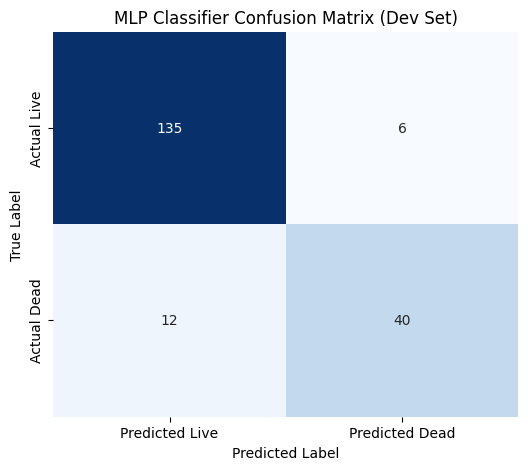

In [15]:
# Plot the confusion matrix for the MLP model via module
from p3_module import plot_confusion
plot_confusion(mlp_dev_confusion_matrix, 'MLP Classifier Confusion Matrix (Dev Set)')

# MLP on extracted features

MLP (feature PCA) - Train Acc: 0.9670 | Dev Acc: 0.9585
MLP (feature PCA) - Train F1:  0.9392 | Dev F1:  0.9216


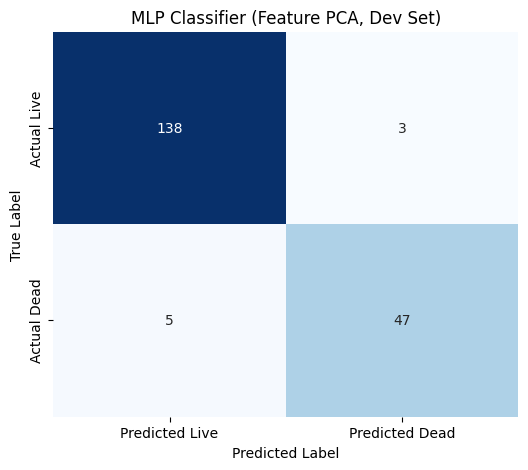

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import time

# Reuse feature PCA outputs
X_train_pca_cur = Z_train
X_dev_pca_cur   = Z_dev

mlp_pipe = Pipeline([
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        max_iter=300,
        alpha=1e-4,
        random_state=SEED
    ))
])

# Measure training time
_t0 = time.time()
mlp_pipe.fit(X_train_pca_cur, y_train)
feat_mlp_train_time_s = time.time() - _t0

# Predictions
y_train_hat = mlp_pipe.predict(X_train_pca_cur)
y_dev_hat   = mlp_pipe.predict(X_dev_pca_cur)

train_feat_mlp_accuracy = accuracy_score(y_train, y_train_hat)
dev_feat_mlp_accuracy   = accuracy_score(y_dev, y_dev_hat)
train_feat_mlp_f1 = f1_score(y_train, y_train_hat)
dev_feat_mlp_f1   = f1_score(y_dev, y_dev_hat)
dev_feat_mlp_auc = roc_auc_score(y_dev, y_dev_hat)

print(f"MLP (feature PCA) - Train Acc: {train_feat_mlp_accuracy:.4f} | Dev Acc: {dev_feat_mlp_accuracy:.4f}")
print(f"MLP (feature PCA) - Train F1:  {train_feat_mlp_f1:.4f} | Dev F1:  {dev_feat_mlp_f1:.4f}")

feat_mlp_dev_confusion_matrix = confusion_matrix(y_dev, y_dev_hat)
plot_confusion(feat_mlp_dev_confusion_matrix, "MLP Classifier (Feature PCA, Dev Set)")

# CNN on raw images

Now we will compare the unsupervised PCA + K-means approach to a well know image classification approach to supervised learning. We will implement a concolutional neural network using the pytorch library to classify the cell images as live or dead.

In [17]:
print("Loaded shapes:", X_train.shape, X_dev.shape, X_test.shape)

Loaded shapes: (1547, 32, 32, 3) (193, 32, 32, 3) (194, 32, 32, 3)


In [18]:
# Import CNN from module
from p3_module import CNN
import torch
from torch import nn

# Instantiate the model and move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=2).to(device)

# Show a short summary-like printout
num_params = sum(p.numel() for p in model.parameters())
print(model.__class__.__name__, f"on {device}")
print(f"Total parameters: {num_params}")

CNN on cpu
Total parameters: 38050


Lets explore the Dev accuracy as a function of batch size and learning rate.

Batch Size: 4, Learning Rate: 1e-05 => Dev Acc: 0.8705
Batch Size: 4, Learning Rate: 0.0001 => Dev Acc: 0.9948
Batch Size: 4, Learning Rate: 0.001 => Dev Acc: 1.0000
Batch Size: 4, Learning Rate: 0.01 => Dev Acc: 0.9741
Batch Size: 8, Learning Rate: 1e-05 => Dev Acc: 0.7306
Batch Size: 8, Learning Rate: 0.0001 => Dev Acc: 0.9948
Batch Size: 8, Learning Rate: 0.001 => Dev Acc: 0.9845
Batch Size: 8, Learning Rate: 0.01 => Dev Acc: 0.9845
Batch Size: 16, Learning Rate: 1e-05 => Dev Acc: 0.7306
Batch Size: 16, Learning Rate: 0.0001 => Dev Acc: 0.9741
Batch Size: 16, Learning Rate: 0.001 => Dev Acc: 0.9896
Batch Size: 16, Learning Rate: 0.01 => Dev Acc: 0.9637
Batch Size: 32, Learning Rate: 1e-05 => Dev Acc: 0.7306
Batch Size: 32, Learning Rate: 0.0001 => Dev Acc: 0.9482
Batch Size: 32, Learning Rate: 0.001 => Dev Acc: 0.9948
Batch Size: 32, Learning Rate: 0.01 => Dev Acc: 0.9948
Batch Size: 64, Learning Rate: 1e-05 => Dev Acc: 0.7306
Batch Size: 64, Learning Rate: 0.0001 => Dev Acc: 0.8964

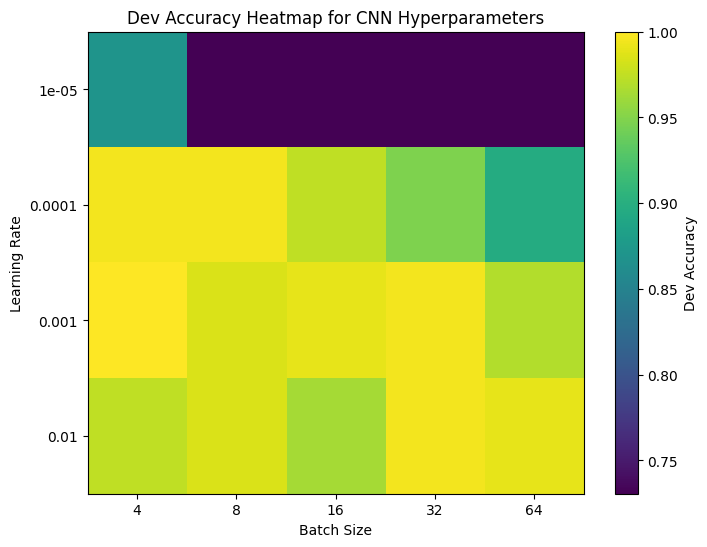

In [19]:
# Hyperparameter search: seeded, re-init model per combo, correct heatmap
from p3_module import CNN, prepare_dataloaders, train_cnn
import torch
import numpy as np
import matplotlib.pyplot as plt

# Use the global SEED defined earlier for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

batch_sizes = [4, 8, 16, 32, 64]
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2]
results = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for batch_size in batch_sizes:
    for lr in learning_rates:
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)

        generator = torch.Generator(device="cpu").manual_seed(SEED)

        model_grid = CNN(num_classes=2).to(device)
        train_loader, dev_loader = prepare_dataloaders(
            X_train, y_train, X_dev, y_dev, batch_size=batch_size
        )

        metrics = train_cnn(model_grid, train_loader, dev_loader, epochs=10, lr=lr, device=device)
        print(f"Batch Size: {batch_size}, Learning Rate: {lr} => Dev Acc: {metrics['last_dev_acc']:.4f}")
        results.append((batch_size, lr, metrics['last_dev_acc']))

# Find the best hyperparameter combination
best_result = max(results, key=lambda x: x[2])
print(
    f"Best Hyperparameters - Batch Size: {best_result[0]}, Learning Rate: {best_result[1]} with Dev Acc: {best_result[2]:.4f}"
)

# Build a heatmap matrix with rows = learning_rates, cols = batch_sizes
acc_grid = np.full((len(learning_rates), len(batch_sizes)), np.nan)
bs_index = {bs: i for i, bs in enumerate(batch_sizes)}
lr_index = {lr: j for j, lr in enumerate(learning_rates)}
for bs, lr, acc in results:
    acc_grid[lr_index[lr], bs_index[bs]] = acc

plt.figure(figsize=(8, 6))
im = plt.imshow(acc_grid, cmap='viridis', aspect='auto')
plt.colorbar(im, label='Dev Accuracy')
plt.xticks(ticks=np.arange(len(batch_sizes)), labels=batch_sizes)
plt.yticks(ticks=np.arange(len(learning_rates)), labels=learning_rates)
plt.xlabel('Batch Size')
plt.ylabel('Learning Rate')
plt.title('Dev Accuracy Heatmap for CNN Hyperparameters')
plt.show()

Train the model using the best hyperparameters.

In [20]:
# Train the CNN model via module utilities
from p3_module import CNN, prepare_dataloaders, train_cnn
#train_loader, dev_loader = prepare_dataloaders(X_train, y_train, X_dev, y_dev, batch_size=4)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

generator = torch.Generator(device="cpu").manual_seed(SEED)
model_grid = CNN(num_classes=2).to(device)

train_loader, dev_loader = prepare_dataloaders(
    X_train, y_train, X_dev, y_dev, batch_size=4
)
metrics = train_cnn(model_grid, train_loader, dev_loader, epochs=10, lr=0.001, device=device)
print(f"Total training time: {metrics['train_time_s']:.2f}s | Dev Acc: {metrics['last_dev_acc']:.4f}")
cnn_train_time_s = metrics['train_time_s']

Total training time: 7.57s | Dev Acc: 1.0000


## Loss Curves

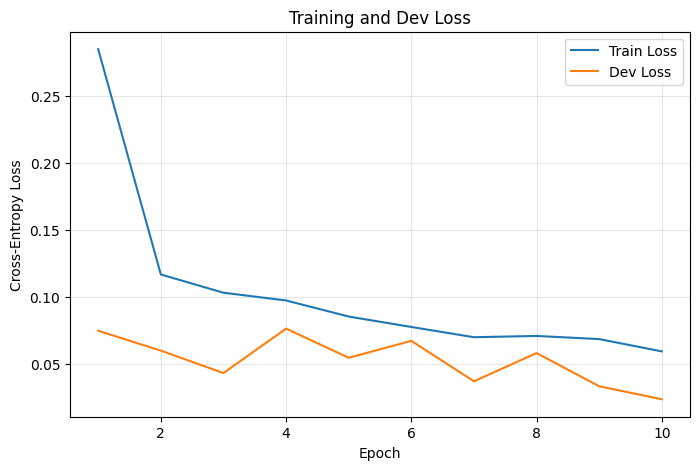

In [21]:
# Plot training and dev loss curves
import matplotlib.pyplot as plt

if len(metrics["train_losses"]) and len(metrics["dev_losses"]):
    epochs_range = list(range(1, len(metrics["train_losses"]) + 1))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, metrics["train_losses"], label='Train Loss')
    plt.plot(epochs_range, metrics["dev_losses"]    , label='Dev Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('Training and Dev Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No recorded losses found. Run the training cell first.")

In [22]:
# Evaluate F1 score on the dev set via module
from p3_module import eval_dev_metrics
m = eval_dev_metrics(model, dev_loader, device=device)
dev_f1 = m['f1']
print(f"Dev F1 score: {dev_f1:.4f}")
dev_f1_cnn = dev_f1
y_true, y_hat = None, None  # placeholders kept for downstream plots

Dev F1 score: 0.2105


In [23]:
# Compute the ROC AUC score on the dev set via module
from p3_module import eval_dev_metrics
m = eval_dev_metrics(model, dev_loader, device=device)
dev_roc_auc_cnn = m['roc_auc']
print(f"Dev ROC AUC score: {dev_roc_auc_cnn:.4f}")

Dev ROC AUC score: 0.4381


CNN Dev Confusion Matrix: 
[[91 50]
 [40 12]]


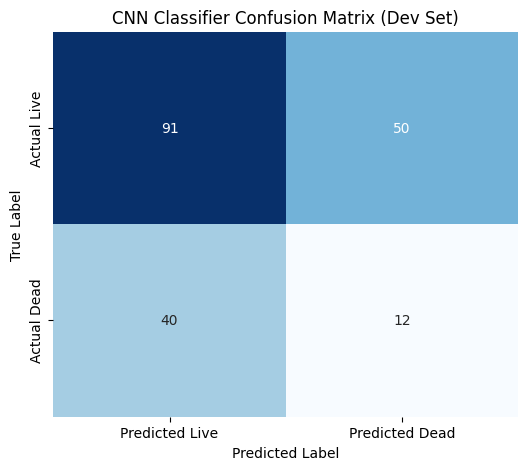

In [24]:
# Confusion matrix for the CNN model via module
from p3_module import eval_dev_metrics, plot_confusion
m = eval_dev_metrics(model, dev_loader, device=device)
cnn_dev_confusion_matrix = m['confusion']
print(f"CNN Dev Confusion Matrix: \n{cnn_dev_confusion_matrix}")
plot_confusion(cnn_dev_confusion_matrix, 'CNN Classifier Confusion Matrix (Dev Set)')

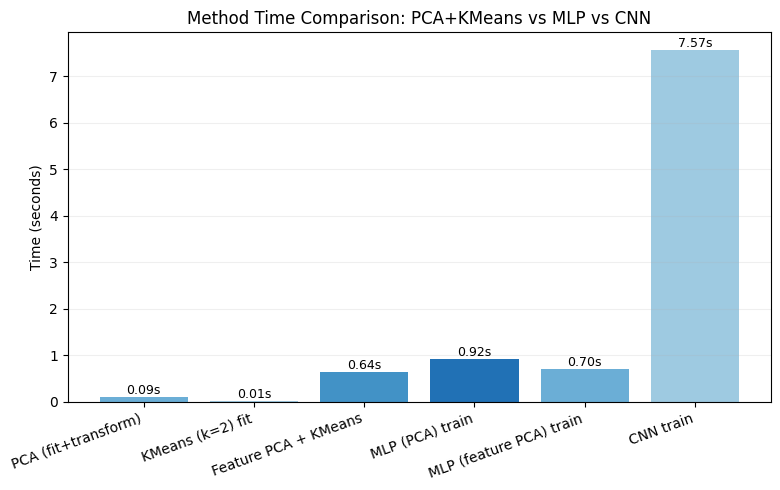

In [25]:
# Compare processing/training times across methods
import matplotlib.pyplot as plt
import numpy as np

# Collect times (ensure variables exist from earlier cells)
times = {
    'PCA (fit+transform)': pca_time_s if 'pca_time_s' in globals() else np.nan,
    'KMeans (k=2) fit': kmeans_time_s if 'kmeans_time_s' in globals() else np.nan,
    'Feature PCA + KMeans': feature_pca_time_s if 'feature_pca_time_s' in globals() else np.nan,
    'MLP (PCA) train': mlp_train_time_s if 'mlp_train_time_s' in globals() else np.nan,
    'MLP (feature PCA) train': feat_mlp_train_time_s if 'feat_mlp_train_time_s' in globals() else np.nan,
    'CNN train': cnn_train_time_s if 'cnn_train_time_s' in globals() else np.nan,
}

labels = list(times.keys())
values = [times[k] for k in labels]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=['#6baed6','#9ecae1','#4292c6','#2171b5'])
plt.ylabel('Time (seconds)')
plt.title('Method Time Comparison: PCA+KMeans vs MLP vs CNN')
plt.xticks(rotation=20, ha='right')
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{v:.2f}s" if not np.isnan(v) else "n/a",
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.grid(axis='y', alpha=0.2)
plt.show()

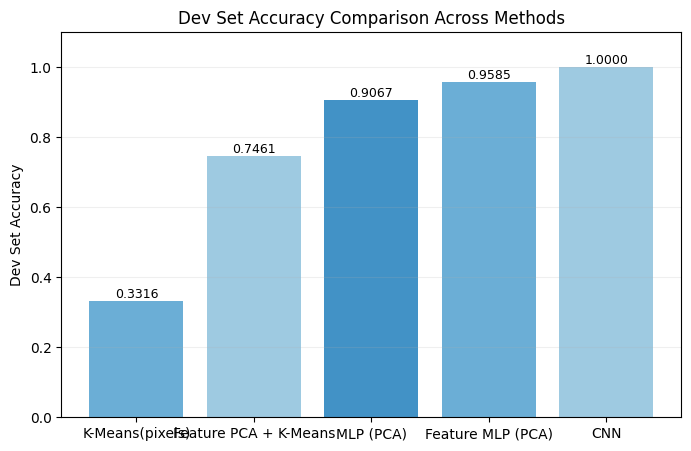

In [26]:
# Compare the Dev Accuracy across methods
import matplotlib.pyplot as plt
methods = ['K-Means(pixels)', 'Feature PCA + K-Means', 'MLP (PCA)', 'Feature MLP (PCA)', 'CNN']
accuracies = [dev_accuracy_kmeans, dev_accuracy_feat_kmeans, dev_mlp_accuracy, dev_feat_mlp_accuracy, metrics["dev_accs"][-1] if len(metrics["dev_accs"]) > 0 else np.nan]
plt.figure(figsize=(8, 5))
bars = plt.bar(methods, accuracies, color=['#6baed6','#9ecae1','#4292c6'])
plt.ylabel('Dev Set Accuracy')
plt.title('Dev Set Accuracy Comparison Across Methods')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{acc:.4f}" if not np.isnan(acc) else "n/a",
             ha='center', va='bottom', fontsize=9)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.2)
plt.show()

## F1 Score Comparison

We compare dev-set F1 scores for PCA+KMeans, MLP (on PCA features), and the CNN.

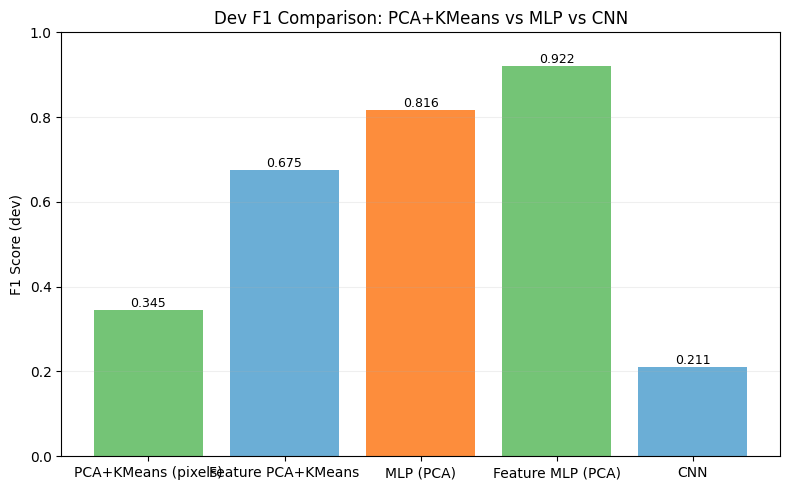

In [27]:
# Bar plot of dev-set F1 scores for the three methods
import numpy as np
import matplotlib.pyplot as plt

# Fetch F1 scores
dev_f1_kmeans_val = dev_f1_kmeans if 'dev_f1_kmeans' in globals() else np.nan
dev_mlp_f1_val = dev_mlp_f1 if 'dev_mlp_f1' in globals() else np.nan
dev_f1_cnn_val = dev_f1_cnn if 'dev_f1_cnn' in globals() else (dev_f1 if 'dev_f1' in globals() else np.nan)

labels = ['PCA+KMeans (pixels)', 'Feature PCA+KMeans', 'MLP (PCA)', 'Feature MLP (PCA)', 'CNN']
values = [dev_f1_kmeans_val, dev_f1_feat_kmeans, dev_mlp_f1_val, dev_feat_mlp_f1, dev_f1_cnn_val]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=['#74c476', '#6baed6', '#fd8d3c'])
plt.ylim(0, 1)
plt.ylabel('F1 Score (dev)')
plt.title('Dev F1 Comparison: PCA+KMeans vs MLP vs CNN')
for bar, v in zip(bars, values):
    height = 0 if np.isnan(v) else v
    label = 'n/a' if np.isnan(v) else f"{v:.3f}"
    plt.text(bar.get_x() + bar.get_width()/2, height, label, ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

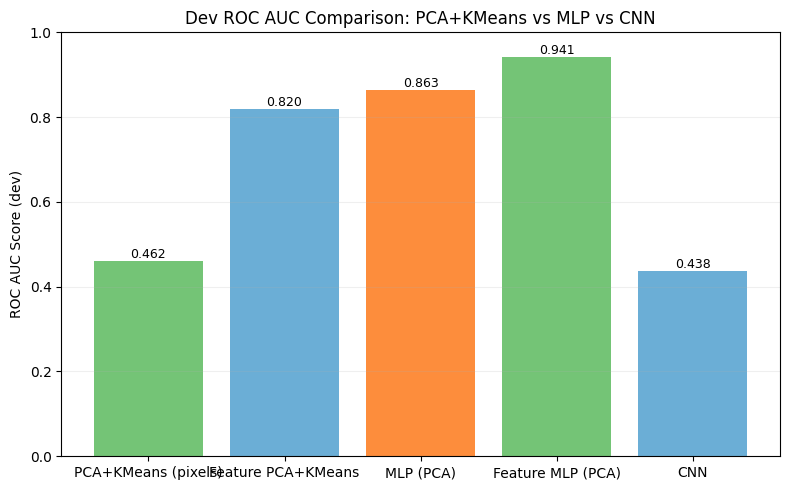

In [28]:
# Compare the ROC AUC scores on the dev set for the three methods
import numpy as np
import matplotlib.pyplot as plt
# Fetch ROC AUC scores
dev_roc_auc_kmeans_val = dev_roc_auc_kmeans if 'dev_roc_auc_kmeans' in globals() else np.nan
dev_mlp_auc_val = mlp_dev_auc if 'mlp_dev_auc' in globals() else np.nan
dev_roc_auc_cnn_val = dev_roc_auc_cnn if 'dev_roc_auc_cnn' in globals() else (dev_roc_auc_cnn if 'dev_roc_auc_cnn' in globals() else np.nan)
labels = ['PCA+KMeans (pixels)', 'Feature PCA+KMeans', 'MLP (PCA)', 'Feature MLP (PCA)', 'CNN']
values = [dev_roc_auc_kmeans_val, dev_roc_auc_feat_kmeans, dev_mlp_auc_val, dev_feat_mlp_auc, dev_roc_auc_cnn_val]
plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=['#74c476', '#6baed6', '#fd8d3c'])
plt.ylim(0, 1)
plt.ylabel('ROC AUC Score (dev)')
plt.title('Dev ROC AUC Comparison: PCA+KMeans vs MLP vs CNN')
for bar, v in zip(bars, values):
    height = 0 if np.isnan(v) else v
    label = 'n/a' if np.isnan(v) else f"{v:.3f}"
    plt.text(bar.get_x() + bar.get_width()/2, height, label, ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


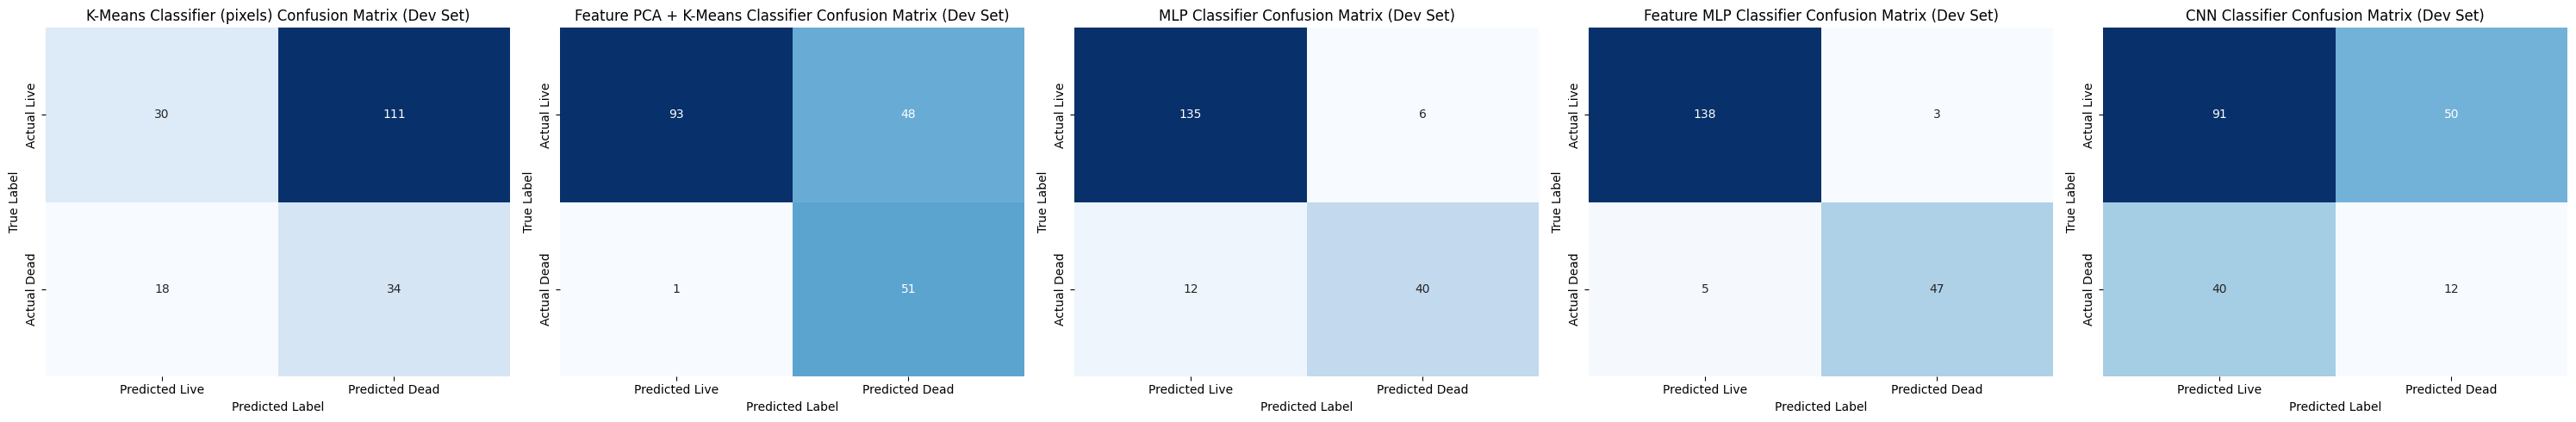

In [29]:
# Display the three confusion matrices side by side using stored arrays
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 5, figsize=(30, 5))
conf_matrices = [
    (dev_confusion_matrix_kmeans, 'K-Means Classifier (pixels)'),
    (dev_confusion_matrix_feat_kmeans, 'Feature PCA + K-Means Classifier'),
    (mlp_dev_confusion_matrix, 'MLP Classifier'),
    (feat_mlp_dev_confusion_matrix, 'Feature MLP Classifier'),
    (cnn_dev_confusion_matrix, 'CNN Classifier')
 ]
for ax, (cm, title) in zip(axes, conf_matrices):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Live', 'Predicted Dead'],
                yticklabels=['Actual Live', 'Actual Dead'], ax=ax)
    ax.set_title(f'{title} Confusion Matrix (Dev Set)')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

# Test results
We test the model that performed the best on the validation (dev) sets. This follows the medical protocol for model selection. The holdout test set is designed to be only evaluated once the best model is selected. This reduces the possibility of picking the model with the best test performance and inadvertantly overfitting to the test set. This is especially true in cases where model performance is very close, but we follow it here in order to adhere to the protocol.

Test Acc: 0.5206
Test ROC AUC: 0.4105
Test Confusion Matrix:
[[92 50]
 [43  9]]


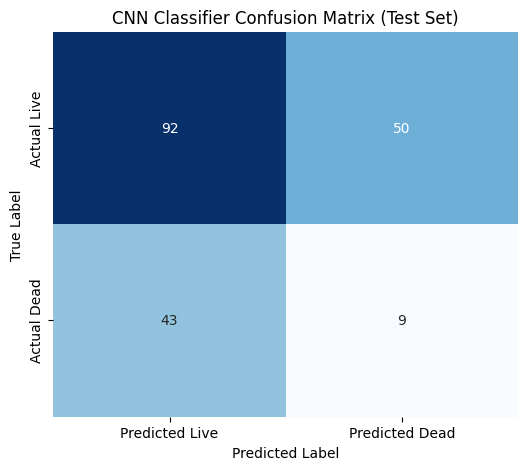

In [30]:
# Plot accuracy, AUC, and confusion matrix for the CNN on the holdout test set
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from p3_module import eval_dev_metrics, plot_confusion

# Build test DataLoader (scale inputs to [0,1])
X_test_t = torch.tensor(X_test).permute(0, 3, 1, 2).float() / 255.0
y_test_t = torch.tensor(y_test).long()
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

# Evaluate metrics on test set
m_test = eval_dev_metrics(model, test_loader, device=device)

cm = m_test['confusion']
# Accuracy from confusion matrix
test_acc = (cm[0,0] + cm[1,1]) / np.sum(cm)
test_auc = m_test['roc_auc']
print(f"Test Acc: {test_acc:.4f}")
print(f"Test ROC AUC: {test_auc:.4f}")
print(f"Test Confusion Matrix:\n{cm}")
plot_confusion(cm, 'CNN Classifier Confusion Matrix (Test Set)')